In [4]:
import pandas as pd

# STEP 1: Creation of a sample file
# Since the dataset is huge (1.6GB), we read it in chunks
# We take atleast 1000 random selected rows and save them to metadata_sample.csv

# Required columns for analysis
needed_columns = [
    "cord_uid", "source_x", "title", "abstract", 
    "publish_time", "journal", "authors", "license"
]

# Read in chunks and sample from each
chunksize = 50000
sample_list = []

for chunk in pd.read_csv("metadata.csv", usecols=needed_columns, chunksize=chunksize):
    sample_list.append(chunk.sample(n=50, random_state=42))  # 50 rows per chunk

# Combine samples into one DataFrame
sample_df = pd.concat(sample_list, ignore_index=True)

# Save smaller dataset
sample_df.to_csv("metadata_sample.csv", index=False)

print("✅ Final sample created: metadata_sample.csv")


✅ Final sample created: metadata_sample.csv


In [7]:
# STEP 2: Load the sample data

df = pd.read_csv("metadata_sample.csv")
print("✅ Sample data loaded successfully: metadata_sample.csv")


✅ Sample data loaded successfully: metadata_sample.csv


In [5]:
# STEP 3: Basic exploration

# Look at first 5 rows
print("\n🔹 First 5 rows of the dataset: \n")
print(df.head())




🔹 First 5 rows of the dataset: 

   cord_uid source_x                                              title  \
0  e067cg5q      PMC  Emerging and Reemerging Infectious Diseases: B...   
1  u8rlo0zw      PMC            Ebola in DR Congo: getting the job done   
2  wtvfow2f      PMC  Unifying evolutionary and thermodynamic inform...   
3  hecaox43      PMC  Editorial Expression of Concern: Experimental ...   
4  9qclu4oq      PMC  European Respiratory Society: 15th Annual Cong...   

    license                                           abstract publish_time  \
0     no-cc  Understanding factors responsible for reemerge...   2005-10-31   
1     no-cc                                                NaN   2020-03-19   
2  cc-by-nc  Computational methods for determining the seco...   2008-10-04   
3     cc-by                                                NaN   2016-10-14   
4     no-cc                                                NaN   2012-08-24   

                                        

In [7]:
# Shape of dataset (rows, columns)
print("\n🔹 Dataset Shape (rows, columns):", df.shape)


🔹 Dataset Shape (rows, columns): (1100, 8)


In [8]:
# Data types and non-null counts
print("\n🔹 Dataset Info: \n")
print(df.info())


🔹 Dataset Info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cord_uid      1100 non-null   object
 1   source_x      1100 non-null   object
 2   title         1099 non-null   object
 3   license       1100 non-null   object
 4   abstract      875 non-null    object
 5   publish_time  1096 non-null   object
 6   authors       1077 non-null   object
 7   journal       999 non-null    object
dtypes: object(8)
memory usage: 68.9+ KB
None


In [ ]:
# Check missing values in all columns
print("\n🔹 Missing values in all 8 columns: \n")
print(df.isnull().sum().head(8))


🔹 Missing values in all 8 columns: 

cord_uid          0
source_x          0
title             1
license           0
abstract        225
publish_time      4
authors          23
journal         101
dtype: int64


In [10]:
# Basic statistics for categorical columns
print("\n🔹 Basic statistics for categorical columns: \n")
print(df.describe())


🔹 Basic statistics for categorical columns: 

        cord_uid source_x        title license  \
count       1100     1100         1099    1100   
unique      1100       20         1097      11   
top     e067cg5q      WHO  Corrigendum     unk   
freq           1      453            2     608   

                                                 abstract publish_time  \
count                                                 875         1096   
unique                                                875          441   
top     Understanding factors responsible for reemerge...         2021   
freq                                                    1          249   

           authors   journal  
count         1077       999  
unique        1074       820  
top     Anonymous,  PLoS One  
freq             2        14  


In [9]:
# PART 2: Data Cleaning and Preprocessing

# STEP 1: Handling Missing Values by filling them Appropiately.
# filling missing title as Untitled 
df['title'] = df['title'].fillna('Untitled')

# filling missing abstract as No Abstract
df['abstract'] = df['abstract'].fillna('No Abstract')

# filling missing publish_time as Unknown
df['publish_time'] = df['publish_time'].fillna('Unknown')

# filling missing authors as Anonymous
df['authors'] = df['authors'].fillna('Anonymous')

# filling missing journal as Unknown
df['journal'] = df['journal'].fillna('Unknown')

# Drop rows where *all values* are NaN.
df = df.dropna(how="all")  

In [11]:
# Step 2: Prepare Data for analysis

# Convert publish_time to datetime format
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')

# Extract year from publish_time for easier time_base analysis
df['publish_year'] = df['publish_time'].dt.year

# Create new column Abstract Word Count, counting number of words in abstract
df['abstract_word_count'] = df['abstract'].apply(lambda x: len(str(x).split()))

# Save cleaned data
df.to_csv("metadata_sample_cleaned.csv", index=False)

# cheking the data after cleaning and preparation
print("\n✅Metadata_sample cleaned and Saved as metadata_sample_cleaned.csv")
print("\n🔹 First 20 rows of the cleaned dataset: \n")
print(df.head(20))


✅Metadata_sample cleaned and Saved as metadata_sample_cleaned.csv

🔹 First 20 rows of the cleaned dataset: 

    cord_uid source_x                                              title  \
0   e067cg5q      PMC  Emerging and Reemerging Infectious Diseases: B...   
1   u8rlo0zw      PMC            Ebola in DR Congo: getting the job done   
2   wtvfow2f      PMC  Unifying evolutionary and thermodynamic inform...   
3   hecaox43      PMC  Editorial Expression of Concern: Experimental ...   
4   9qclu4oq      PMC  European Respiratory Society: 15th Annual Cong...   
5   uovk5fsn      PMC  Zu Joggern 10 Meter Abstand einhalten!: COVID-...   
6   542e5h1u      PMC     Coronavirus disease: challenges for psychiatry   
7   p11oyt24      PMC  ‘Guarantee UK standards will be protected’, sa...   
8   usvz287e      PMC  Comprehensive Interactome Analysis Reveals tha...   
9   w6sh9f3h      PMC  China’s Institutional Mechanisms for Influenza...   
10  7l81mzwn      PMC  A Framework for Feature Selecti

In [25]:
# =========================================
# Part 3: Data Analysis and Visualization
# =========================================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# -------------------------------
# STEP 1: Load the cleaned dataset
# -------------------------------
df = pd.read_csv("metadata_sample_cleaned.csv")

# Ensure publish_year is integer (not float)
df['publish_year'] = df['publish_year'].fillna(0).astype(int)

# -------------------------------
# STEP 2: Basic Analysis
# -------------------------------

# 2.1 Count papers by publication year
papers_per_year = df['publish_year'].value_counts().sort_index()
print("✅ Papers per year:\n", papers_per_year.tail(5), "\n")


# 2.2 Identify top journals publishing COVID-19 research
top_journals = df['journal'].value_counts().head(10)
print("\n🔹 Top 10 journals publishing COVID-19 research: \n", top_journals)

# 2.3 Most frequent words in titles
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)   # keep only letters
    return text

all_titles = " ".join(df['title'].dropna().apply(clean_text))
word_counts = Counter(all_titles.split())
most_common_words = word_counts.most_common(5)
print("\n🔹 Most common words in titles: \n", most_common_words)

✅ Papers per year:
 publish_year
2018      4
2019      5
2020    197
2021    231
2022     86
Name: count, dtype: int64 


🔹 Top 10 journals publishing COVID-19 research: 
 journal
Unknown                            101
PLoS One                            14
Int J Environ Res Public Health     12
bioRxiv                              9
Lancet                               8
Cureus                               7
BMJ                                  6
Front Public Health                  6
Front Immunol                        6
Science                              5
Name: count, dtype: int64

🔹 Most common words in titles: 
 [('of', 757), ('in', 615), ('the', 572), ('and', 546), ('covid', 498)]


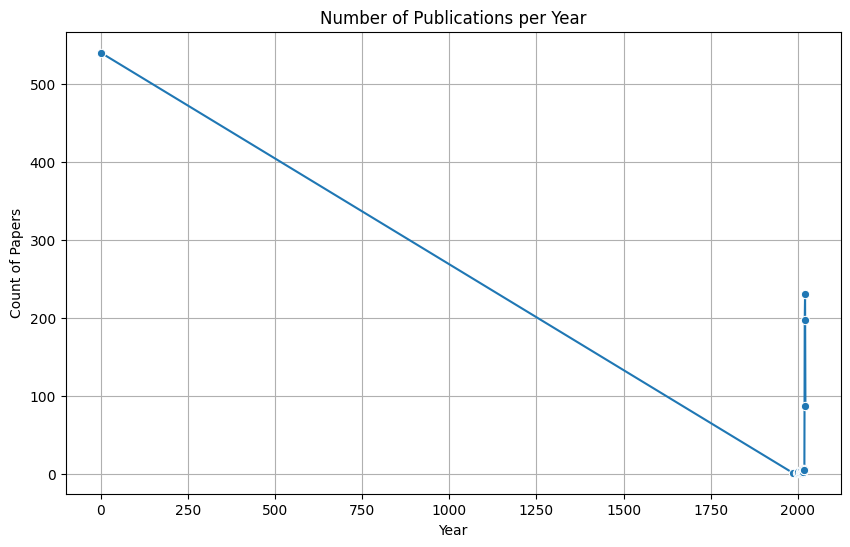

In [13]:
# -------------------------------
# STEP 3: Visualization
# -------------------------------

# 3.1 Plot number of publications over time
plt.figure(figsize=(10,6))
sns.lineplot(x=papers_per_year.index, y=papers_per_year.values, marker="o")
plt.title("Number of Publications per Year")
plt.xlabel("Year")
plt.ylabel("Count of Papers")
plt.grid(True)
plt.show()

C:\Users\CONVERTER\AppData\Local\Temp\ipykernel_3968\3655450183.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_journals.values, y=top_journals.index, palette="viridis")


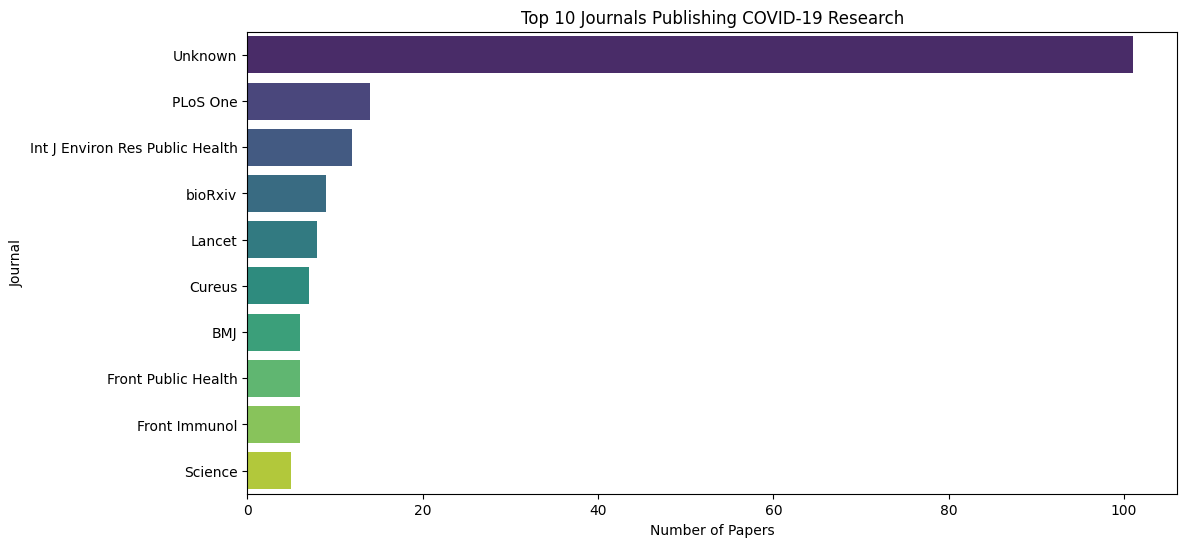

In [14]:
# 3.2 Bar chart of top publishing journals
plt.figure(figsize=(12,6))
sns.barplot(x=top_journals.values, y=top_journals.index, palette="viridis")
plt.title("Top 10 Journals Publishing COVID-19 Research")
plt.xlabel("Number of Papers")
plt.ylabel("Journal")
plt.show()

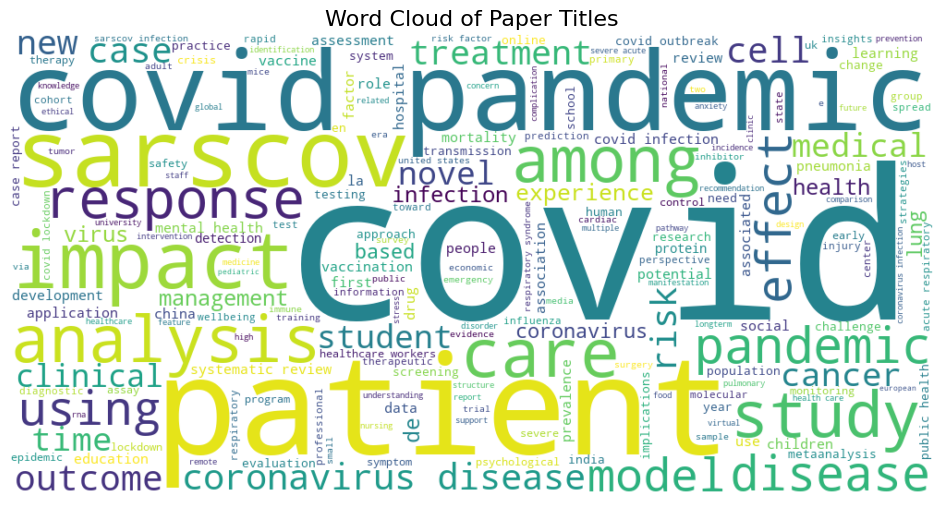

In [15]:
# 3.3 Word Cloud of paper titles
wordcloud = WordCloud(width=1000, height=500, background_color="white",
                      colormap="viridis").generate(all_titles)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Paper Titles", fontsize=16)
plt.show()

C:\Users\CONVERTER\AppData\Local\Temp\ipykernel_3968\1843522960.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sources.index, y=top_sources.values, palette="Set2")


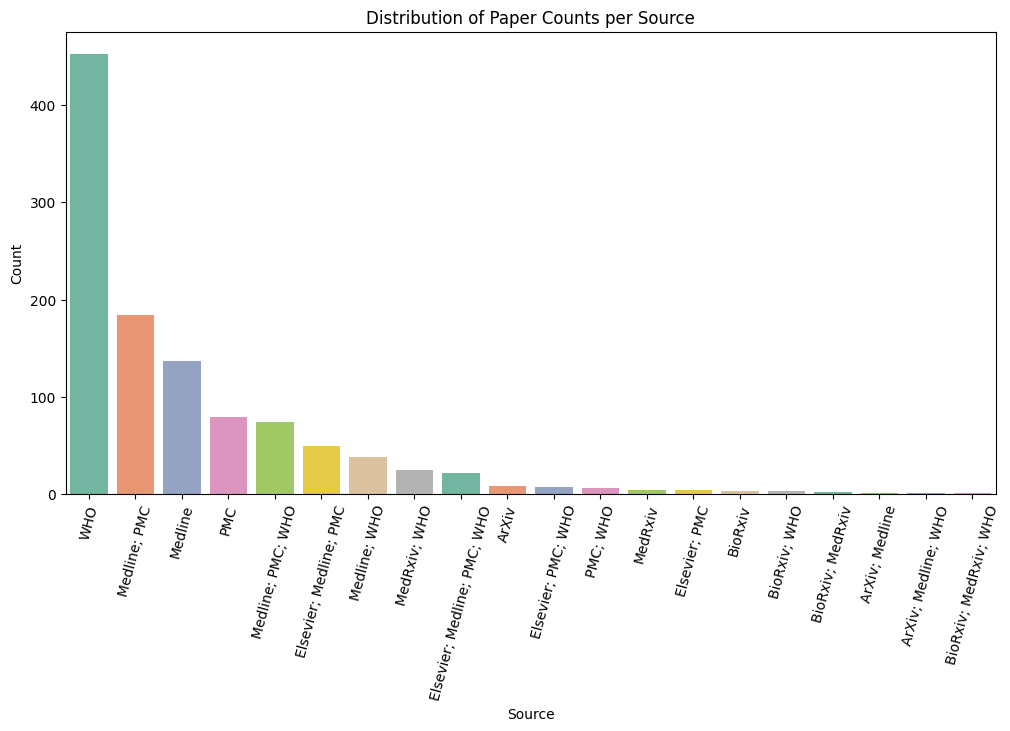

In [23]:
# Plotting a Distribution of Paper Counts per Source.
# We will pick few top 20 sources to represent over 1000 sources available.
# Count papers per source
source_counts = df['source_x'].value_counts()

# Pick top 20 sources
top_sources = source_counts.head(20)

plt.figure(figsize=(12,6))
sns.barplot(x=top_sources.index, y=top_sources.values, palette="Set2")
plt.title("Distribution of Paper Counts per Source")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()